4422102/4422102 [==============================] - 0s 0us/step


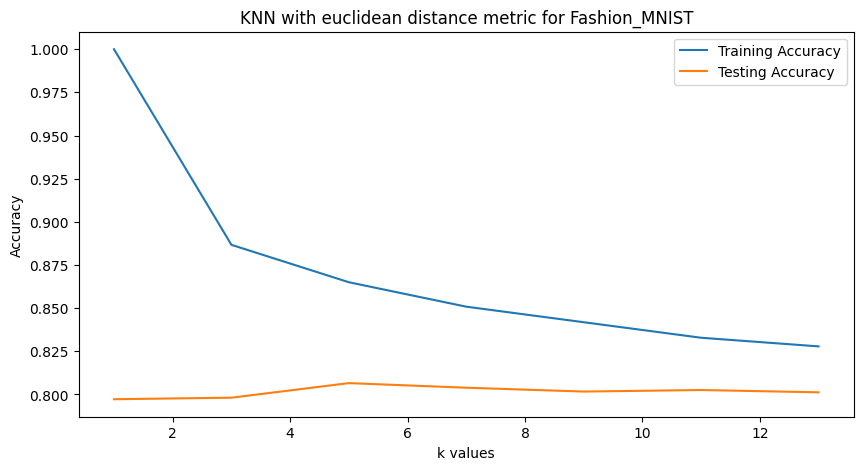

Best k value for euclidean metric: 5
Training Accuracy: 1.0
Testing Accuracy: 0.8065555555555556
F1 Score: 0.8077283366490814


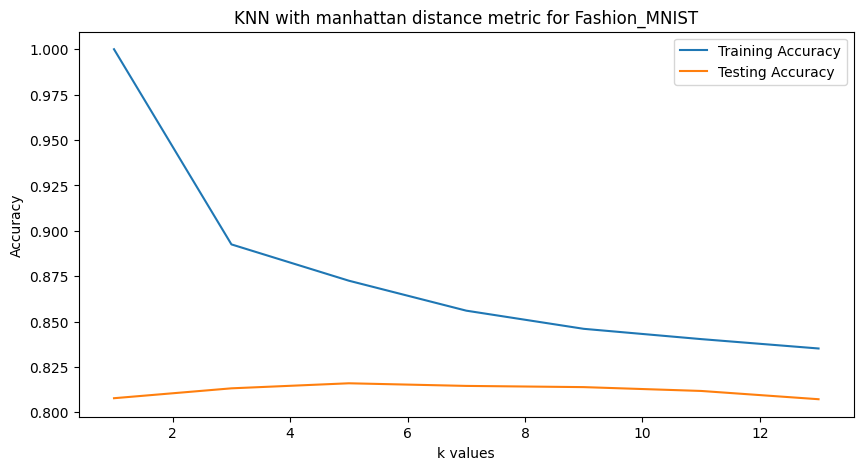

Best k value for manhattan metric: 5
Training Accuracy: 1.0
Testing Accuracy: 0.816
F1 Score: 0.8162087243653717


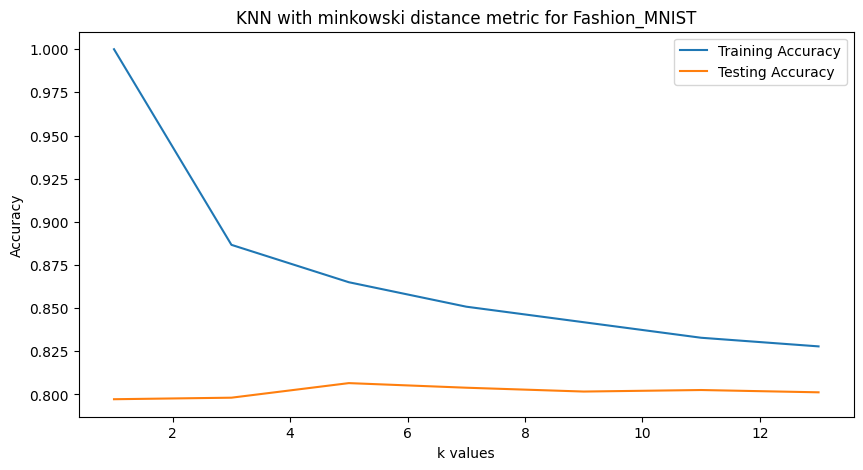

Best k value for minkowski metric: 5
Training Accuracy: 1.0
Testing Accuracy: 0.8065555555555556
F1 Score: 0.8077283366490814


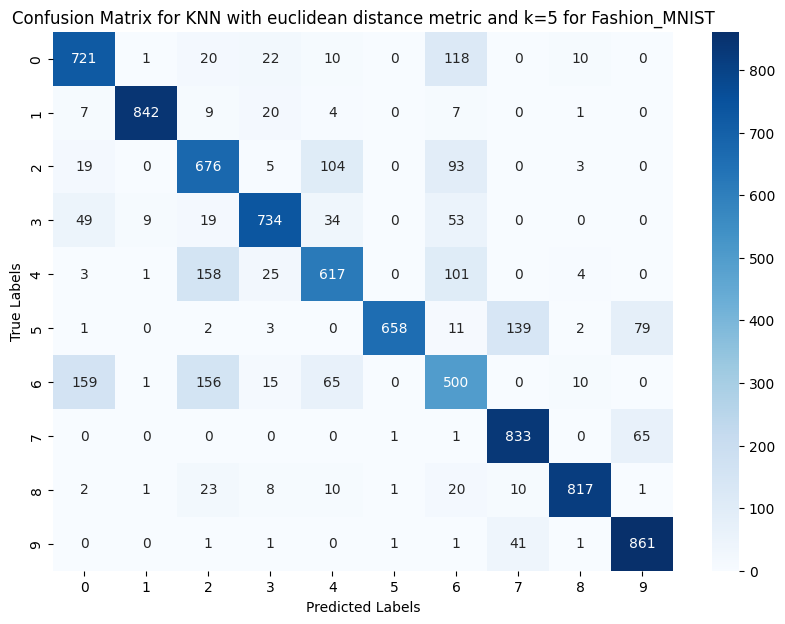

Classification Report for Fashion_MNIST:
              precision    recall  f1-score   support

           0       0.75      0.80      0.77       902
           1       0.98      0.95      0.97       890
           2       0.64      0.75      0.69       900
           3       0.88      0.82      0.85       898
           4       0.73      0.68      0.70       909
           5       1.00      0.74      0.85       895
           6       0.55      0.55      0.55       906
           7       0.81      0.93      0.87       900
           8       0.96      0.91      0.94       893
           9       0.86      0.95      0.90       907

    accuracy                           0.81      9000
   macro avg       0.82      0.81      0.81      9000
weighted avg       0.82      0.81      0.81      9000



In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from tensorflow import keras

# Download Fashion MNIST dataset
fashion_mnist = keras.datasets.fashion_mnist
(trImages, trLabels), (tImages, tLabels) = fashion_mnist.load_data()

# Flatten the images
trImages_flat = trImages.reshape((trImages.shape[0], -1))
tImages_flat = tImages.reshape((tImages.shape[0], -1))

# Use smaller subsets for initial testing
X_train_fashion, X_val_fashion, y_train_fashion, y_val_fashion = train_test_split(
    trImages_flat, trLabels, test_size=0.9, random_state=42
)
X_val_fashion, X_test_fashion, y_val_fashion, y_test_fashion = train_test_split(
    tImages_flat, tLabels, test_size=0.9, random_state=42
)

def run_knn(X_train, X_test, y_train, y_test, dataset_name, distance_metrics=['euclidean', 'manhattan', 'minkowski'], k_range=(1, 15, 2)):
    results = {}

    for metric in distance_metrics:
        # Initialize lists to store accuracy scores
        train_accuracy = []
        test_accuracy = []
        f1_scores = []

        # Perform KNN with different k values
        k_values = list(range(*k_range))
        for k in k_values:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
            knn.fit(X_train, y_train)
            y_pred = knn.predict(X_test)

            train_accuracy.append(knn.score(X_train, y_train))
            test_accuracy.append(knn.score(X_test, y_test))
            f1_scores.append(f1_score(y_test, y_pred, average='weighted'))

        # Plot accuracy vs k values
        plt.figure(figsize=(10, 5))
        plt.plot(k_values, train_accuracy, label='Training Accuracy')
        plt.plot(k_values, test_accuracy, label='Testing Accuracy')
        plt.xlabel('k values')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.title(f'KNN with {metric} distance metric for {dataset_name}')
        plt.savefig(f'knn_accuracy_{dataset_name}_{metric}.png')
        plt.show()

        # Store results for comparison
        best_k = k_values[test_accuracy.index(max(test_accuracy))]
        results[metric] = {
            'best_k': best_k,
            'train_accuracy': max(train_accuracy),
            'test_accuracy': max(test_accuracy),
            'f1_score': max(f1_scores)
        }

        print(f'Best k value for {metric} metric: {best_k}')
        print(f'Training Accuracy: {max(train_accuracy)}')
        print(f'Testing Accuracy: {max(test_accuracy)}')
        print(f'F1 Score: {max(f1_scores)}')

    # Choose the best distance metric and k value for which you want to plot the confusion matrix
    best_metric = 'euclidean'  # Replace with the best metric from your results
    best_k = results[best_metric]['best_k']

    # Train KNN with the best parameters
    knn_best = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
    knn_best.fit(X_train, y_train)

    # Predict on the test set
    y_test_pred = knn_best.predict(X_test)

    # Compute the confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)

    # Plot the confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Confusion Matrix for KNN with {best_metric} distance metric and k={best_k} for {dataset_name}')
    plt.savefig(f'confusion_matrix_{dataset_name}_{best_metric}_k{best_k}.png')
    plt.show()

    # Print classification report
    print(f"Classification Report for {dataset_name}:")
    print(classification_report(y_test, y_test_pred))

# Run KNN for Fashion MNIST
run_knn(X_train_fashion, X_test_fashion, y_train_fashion, y_test_fashion, 'Fashion_MNIST')
